Saving sample_data(14).jpg to sample_data(14) (6).jpg


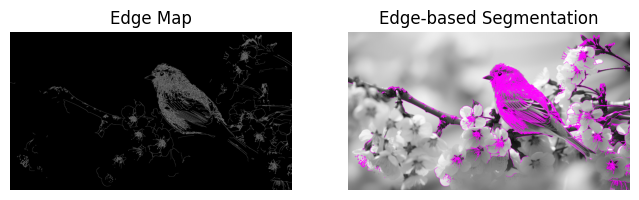

In [ ]:
# PROGRAM-3
# Edge Detection for Image Segmentation

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image in grayscale and color
img = cv2.imread(image_path, 0)
img_1 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)

if img is None:
    raise ValueError("Failed to load image!")

# Step 1: Edge detection
edges = cv2.Canny(img, 50, 200)

# Step 2: Find contours (segmentation)
# syntax - findContours(image, mode, method)
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Convert to color to draw contours
segmented = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw contours
cv2.drawContours(segmented, contours, -1, (256, 0, 256), 2)

# Display
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Edge Map")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Edge-based Segmentation")
plt.imshow(segmented, cmap='gray')
plt.axis("off")

plt.show()


Saving photo_6253498312153565982_m.jpg to photo_6253498312153565982_m.jpg


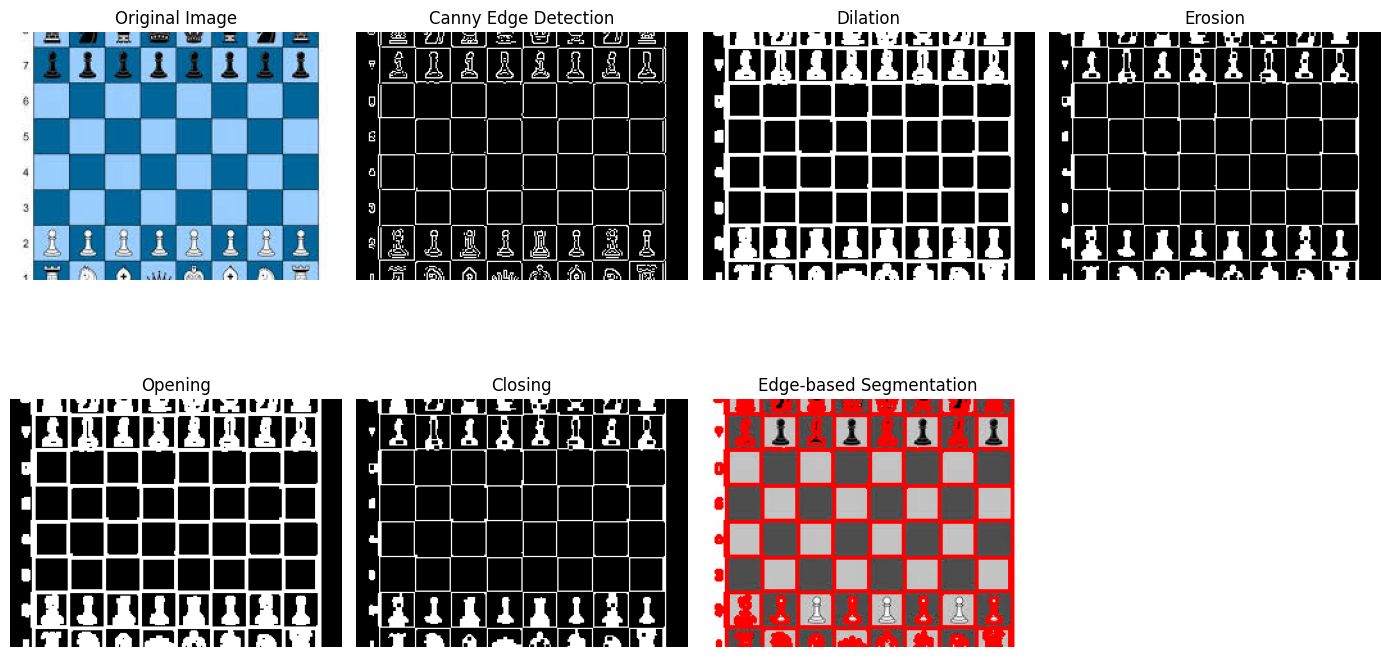

In [ ]:
#Morphological Operations
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Upload NEW image
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read NEW image
img_gray = cv2.imread(image_path, 0)
img_color = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

if img_gray is None:
    raise ValueError("Failed to load image")

# Recompute edges for NEW image
edges = cv2.Canny(img_gray, 100, 200)

# --------------------------------
# Define kernel for morphological operations
kernel = np.ones((3, 3), np.uint8)

# Dilation - thickens edges
dilated = cv2.dilate(edges, kernel, iterations=1)

# Erosion - thins edges / removes noise
eroded = cv2.erode(dilated, kernel, iterations=1)

# Opening - erosion followed by dilation
opening = cv2.morphologyEx(dilated, cv2.MORPH_OPEN, kernel)

# Closing - dilation followed by erosion
closing = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

segmented = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(segmented, contours, -1, (255, 0, 0), 2)

# --------------------------------
# Step 5: Display Results
# --------------------------------
plt.figure(figsize=(14, 8))

plt.subplot(2, 4, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.title("Dilation")
plt.imshow(dilated, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.title("Erosion")
plt.imshow(eroded, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.title("Opening")
plt.imshow(opening, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.title("Closing")
plt.imshow(closing, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.title("Edge-based Segmentation")
plt.imshow(segmented)
plt.axis("off")

plt.tight_layout()
plt.show()